In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

print("Libraries imported successfully")



Libraries imported successfully


In [4]:
import pandas as pd

train = pd.read_csv('/content/Titanic_train.csv')
test = pd.read_csv('/content/Titanic_test.csv')

train.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df = train
df.shape



(891, 12)

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:

train.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


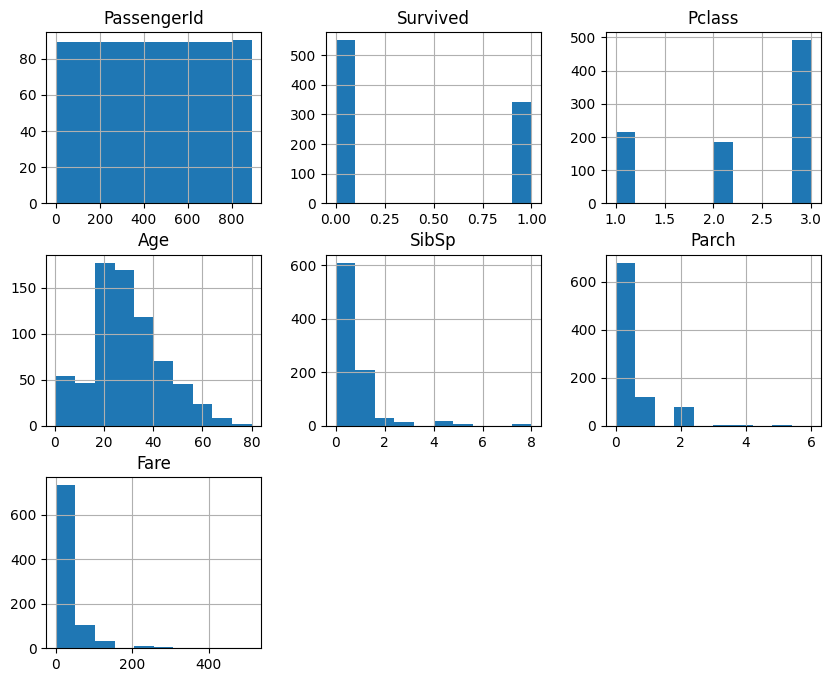

In [8]:
train.hist(figsize=(10,8))
plt.show()

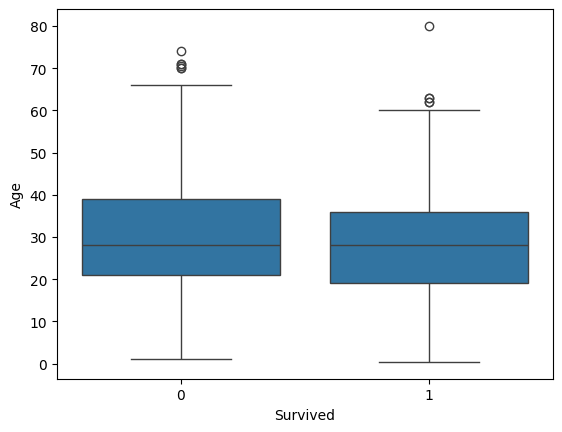

In [9]:
sns.boxplot(x='Survived', y='Age', data=train)
plt.show()

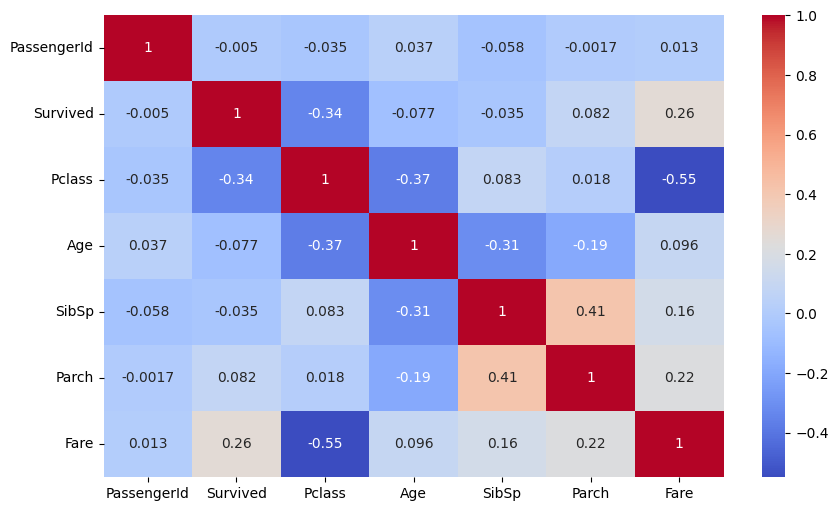

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(train.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.show()

In [11]:
train['Age'].fillna(train['Age'].mean(), inplace=True)
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)

train['Sex'] = train['Sex'].map({'male':0, 'female':1})
train = pd.get_dummies(train, columns=['Embarked'], drop_first=True)

train.head()

/tmp/ipykernel_4662/3579875615.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Age'].fillna(train['Age'].mean(), inplace=True)
/tmp/ipykernel_4662/3579875615.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,False,True


In [12]:
X = train[['Pclass','Sex','Age','Fare']]
y = train['Survived']
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,False,True


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [15]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7988826815642458
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



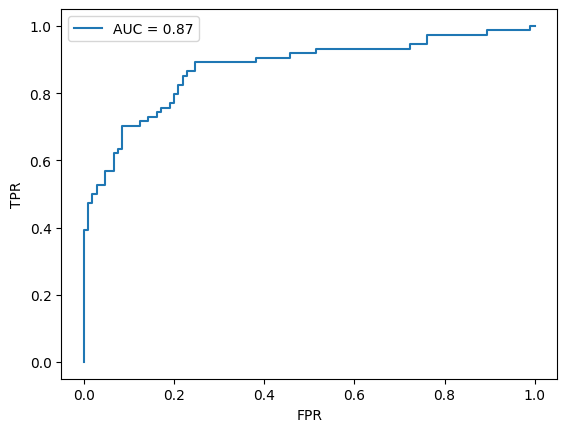

In [16]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.legend()
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

In [17]:

import pickle

pickle.dump(model, open('model.pkl', 'wb'))

print("Model saved successfully")

Model saved successfully


## Deployment using Streamlit

The trained Logistic Regression model is deployed using Streamlit.

The model is saved as 'model.pkl' and used in a Streamlit application where users can input values such as Pclass, Age, Fare, and Sex to predict survival.

This enables real-time prediction using a simple web interface.

In [20]:
!pip install streamlit

# Streamlit App Code

import streamlit as st
import pandas as pd
import pickle

model = pickle.load(open('model.pkl', 'rb'))

st.title("Titanic Survival Prediction")

pclass = st.selectbox("Passenger Class", [1,2,3])
age = st.slider("Age", 0, 80, 25)
fare = st.number_input("Fare", 0.0, 500.0, 50.0)
sex = st.selectbox("Sex", ["male","female"])

sex = 1 if sex == "male" else 0

input_df = pd.DataFrame({
    'Pclass':[pclass],
    'Age':[age],
    'Fare':[fare],
    'Sex':[sex]
})

if st.button("Predict"):
    result = model.predict(input_df)
    if result[0] == 1:
        st.success("Survived")
    else:
        st.error("Not Survived")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 104.1 MB/s eta 0:00:00


2026-03-24 13:57:51.851 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 13:57:52.182 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-24 13:57:52.184 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 13:57:52.187 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 13:57:52.189 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 13:57:52.191 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 13:57:52.195 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 13:57:52.198 Thread 'MainThread': mi

Interpretation
The logistic regression model coefficients show how each feature affects survival probability.

Features like Sex, Fare, and Pclass have a significant impact on survival.

Female passengers have higher chances of survival compared to males.
Passengers with higher fare tend to have higher survival probability.
Lower class (higher Pclass value) passengers have lower survival chances.
Thus, these features play an important role in predicting survival.

## Interview Questions

1.What is the difference between precision and recall?
 Precision and Recall are evaluation metrics used in classification problems.

Precision:
Precision measures how many of the predicted positive cases are actually correct.
Formula: Precision = True Positives / (True Positives + False Positives)

Recall:
Recall measures how many actual positive cases are correctly identified by the model.
Formula: Recall = True Positives / (True Positives + False Negatives)

Difference:
Precision focuses on accuracy of positive predictions, while Recall focuses on capturing all actual positives.

2. What is cross-validation, and why is it important in binary classification?
Cross-validation is a technique used to evaluate the performance of a model by dividing the dataset into multiple parts.

In this method, the model is trained on some parts of the data and tested on the remaining part. This process is repeated multiple times.

Importance:
- It helps in getting a more reliable estimate of model performance.
- It reduces overfitting.
- It ensures that the model performs well on unseen data.